# Brain Tumor Detection Pipeline

**Reproduction:** 2-D DWT + GLCM texture features + MLP classifier + Fuzzy C-Means segmentation  
**Dataset:** `masoudnickparvar/brain-tumor-mri-dataset` — glioma / meningioma / pituitary / no-tumor


| Step | What happens |
|------|-------------|
| 1 | Load images and assign binary + 4-class labels |
| 2 | Apply DWT > extract GLCM + statistical features from subbands |
| 3 | Train + evaluate **binary** MLP (tumour vs. no-tumour) |
| 4 | Train + evaluate **multiclass** MLP (4-way) |
| 5 | Fuzzy C-Means segmentation demo |

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path('..') / 'src'))

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc
from sklearn.preprocessing import StandardScaler

from data         import load_dataset, load_images, dataset_summary, CLASS_NAMES
from preprocessing import extract_features_batch, feature_names, save_features, load_features
from model        import make_model, fit, evaluate, DEVICE
from segmentation import fuzzy_cmeans_segment, visualize_segmentation

DATA_DIR       = Path('../data')
CACHE_DIR      = Path('../data/.cache')
CACHE_DIR.mkdir(exist_ok=True)

IMAGE_SIZE     = (256, 256)
WAVELET        = 'db1'
WAVELET_LEVEL  = 1

plt.rcParams['figure.dpi'] = 110
print(f'Device: {DEVICE}')

Device: cpu


## 1. Load Dataset

In [2]:
splits = load_dataset(DATA_DIR)
dataset_summary(splits)


TRAIN  (n=4760)
  Class           Count  Binary
  ------------------------------
  glioma           1190    tumor
  meningioma       1190    tumor
  notumor          1190  notumor
  pituitary        1190    tumor
  total            4760  tumor=3570 / notumor=1190

VAL  (n=840)
  Class           Count  Binary
  ------------------------------
  glioma            210    tumor
  meningioma        210    tumor
  notumor           210  notumor
  pituitary         210    tumor
  total             840  tumor= 630 / notumor=210

TEST  (n=1600)
  Class           Count  Binary
  ------------------------------
  glioma            400    tumor
  meningioma        400    tumor
  notumor           400  notumor
  pituitary         400    tumor
  total            1600  tumor=1200 / notumor=400


## 2. Feature Extraction

Features are cached to `data/.cache/` after the first run so subsequent runs are instant.

In [3]:
CACHE_FILE = CACHE_DIR / f'features_{WAVELET}_L{WAVELET_LEVEL}.npz'

if CACHE_FILE.exists():
    print('Loading cached features...')
    c = load_features(CACHE_FILE)
    X_train_raw = c['X_train']
    X_val_raw   = c['X_val']
    X_test_raw  = c['X_test']
else:
    print('Extracting features - first run takes several minutes...')
    raw = {}
    for sname in ('train', 'val', 'test'):
        imgs = load_images(splits[sname]['paths'], image_size=IMAGE_SIZE)
        raw[f'X_{sname}'] = extract_features_batch(
            imgs, wavelet=WAVELET, level=WAVELET_LEVEL, desc=sname)
        del imgs
    X_train_raw = raw['X_train']
    X_val_raw   = raw['X_val']
    X_test_raw  = raw['X_test']
    save_features(CACHE_FILE,
                  X_train=X_train_raw, X_val=X_val_raw, X_test=X_test_raw)
    print(f'Cached to {CACHE_FILE}')

n_feats = X_train_raw.shape[1]
print(f'Feature dim : {n_feats}')
print(f'Train {X_train_raw.shape}  Val {X_val_raw.shape}  Test {X_test_raw.shape}')
print(f'First 5 names: {feature_names(WAVELET, WAVELET_LEVEL)[:5]}')

Loading cached features...
Feature dim : 44
Train (4760, 44)  Val (840, 44)  Test (1600, 44)
First 5 names: ['cA_contrast', 'cA_dissimilarity', 'cA_homogeneity', 'cA_energy', 'cA_correlation']


In [4]:
scaler  = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_val   = scaler.transform(X_val_raw)
X_test  = scaler.transform(X_test_raw)

# Labels
y_train_bin = splits['train']['y_binary']
y_val_bin   = splits['val']['y_binary']
y_test_bin  = splits['test']['y_binary']

y_train_mc  = splits['train']['y_multiclass']
y_val_mc    = splits['val']['y_multiclass']
y_test_mc   = splits['test']['y_multiclass']

INPUT_DIM = X_train.shape[1]
print(f'Features standardised - input dim = {INPUT_DIM}')

Features standardised - input dim = 44


In [5]:
# Shared plotting helpers

def plot_history(history, title='Training History'):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    ax1.plot(history['train_loss'], label='train')
    ax1.plot(history['val_loss'],   label='val')
    ax1.set(xlabel='Epoch', ylabel='CE Loss', title='Loss')
    ax1.legend()
    ax2.plot(history['train_acc'], label='train')
    ax2.plot(history['val_acc'],   label='val')
    ax2.set(xlabel='Epoch', ylabel='Accuracy', title='Accuracy')
    ax2.legend()
    fig.suptitle(title, fontsize=13)
    plt.tight_layout()
    plt.show()


def plot_cm(true, pred, labels, title='Confusion Matrix'):
    cm  = confusion_matrix(true, pred)
    n   = len(labels)
    fig, ax = plt.subplots(figsize=(3 + n, 2 + n))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=labels, yticklabels=labels, ax=ax)
    ax.set(xlabel='Predicted', ylabel='True', title=title)
    plt.tight_layout()
    plt.show()

## 3. Binary Classification: Tumour vs. No-Tumour

Stopped at epoch  53  |  best val acc: 0.9869


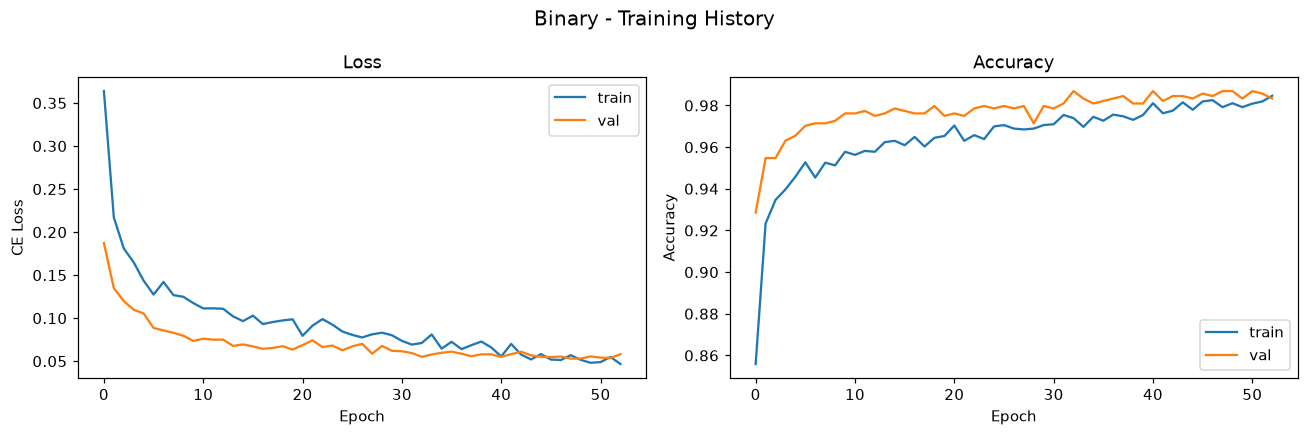

In [6]:
bin_model   = make_model(INPUT_DIM, task='binary')
history_bin = fit(
    bin_model, X_train, y_train_bin, X_val, y_val_bin,
    epochs=150, lr=1e-3, patience=20
)
plot_history(history_bin, 'Binary - Training History')

Binary test accuracy: 0.9450

              precision    recall  f1-score   support

    no-tumor       0.82      0.99      0.90       400
       tumor       1.00      0.93      0.96      1200

    accuracy                           0.94      1600
   macro avg       0.91      0.96      0.93      1600
weighted avg       0.95      0.94      0.95      1600



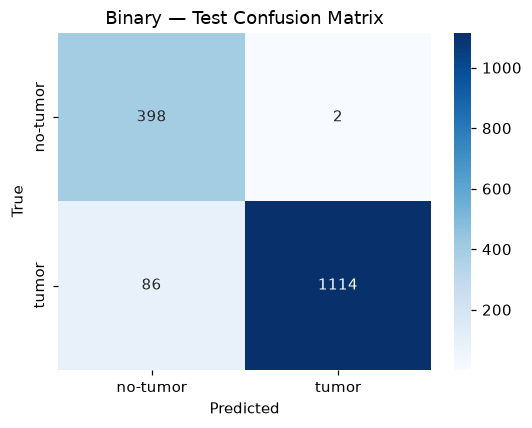

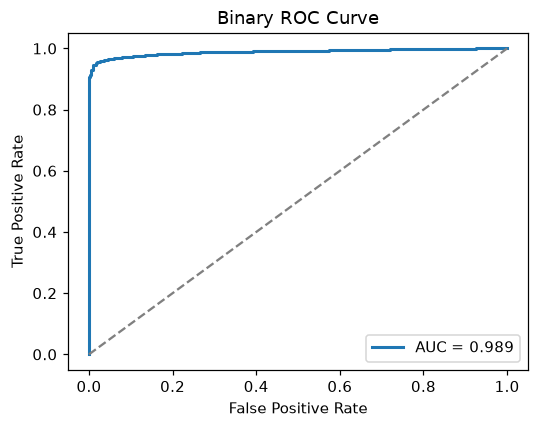

In [7]:
res_bin = evaluate(bin_model, X_test, y_test_bin)
print(f'Binary test accuracy: {res_bin["accuracy"]:.4f}')
print()
print(classification_report(
    res_bin['true_labels'], res_bin['predictions'],
    target_names=['no-tumor', 'tumor']
))
plot_cm(
    res_bin['true_labels'], res_bin['predictions'],
    labels=['no-tumor', 'tumor'],
    title='Binary — Test Confusion Matrix'
)

# ROC / AUC
fpr, tpr, _ = roc_curve(res_bin['true_labels'], res_bin['probabilities'][:, 1])
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(5, 4))
plt.plot(fpr, tpr, lw=2, label=f'AUC = {roc_auc:.3f}')
plt.plot([0, 1], [0, 1], '--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Binary ROC Curve')
plt.legend()
plt.tight_layout()
plt.show()

## 4. Multiclass Classification: Glioma / Meningioma / Pituitary / No-Tumor

Stopped at epoch 135  |  best val acc: 0.9179


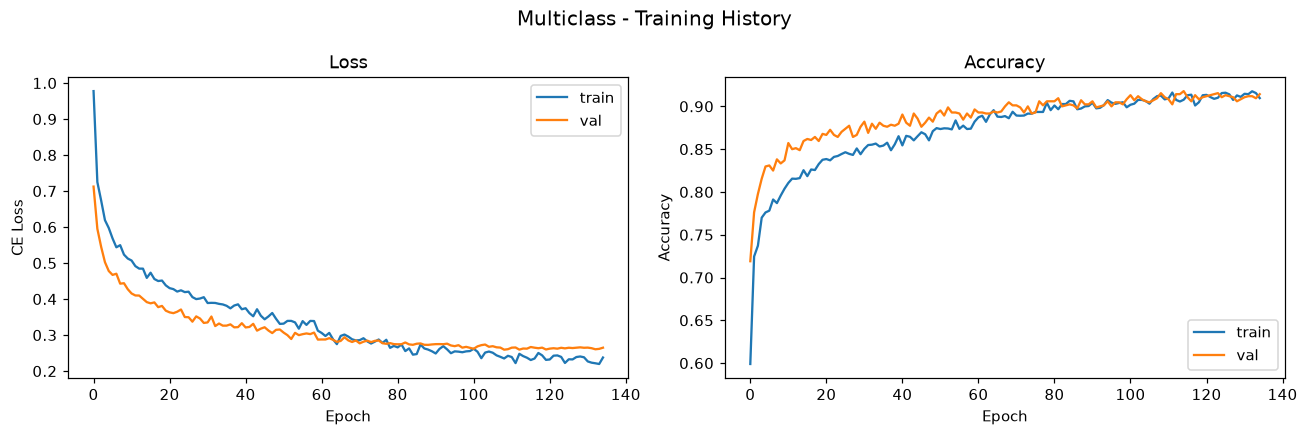

In [8]:
mc_model   = make_model(INPUT_DIM, task='multiclass')
history_mc = fit(
    mc_model, X_train, y_train_mc, X_val, y_val_mc,
    epochs=150, lr=1e-3, patience=20
)
plot_history(history_mc, 'Multiclass - Training History')

Multiclass test accuracy: 0.8400

              precision    recall  f1-score   support

      glioma       0.85      0.62      0.72       400
  meningioma       0.75      0.79      0.77       400
     notumor       0.85      0.99      0.92       400
   pituitary       0.91      0.96      0.94       400

    accuracy                           0.84      1600
   macro avg       0.84      0.84      0.83      1600
weighted avg       0.84      0.84      0.83      1600



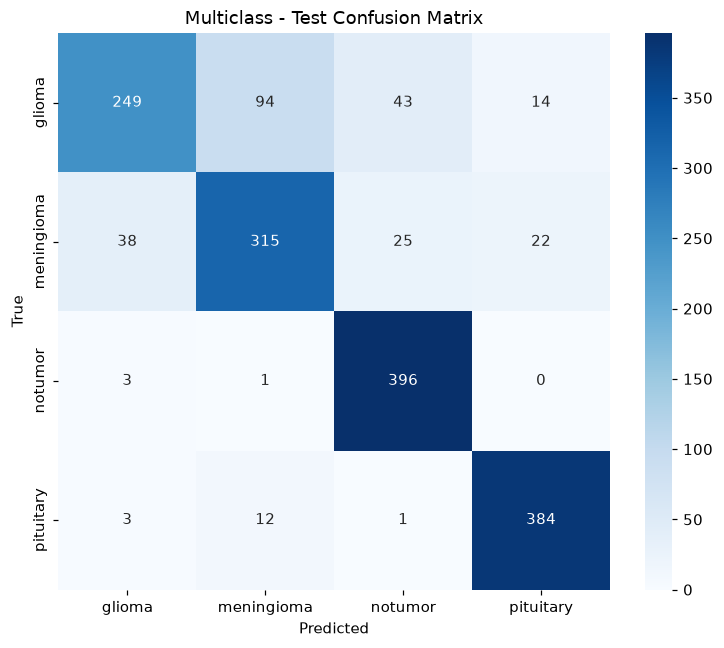

In [9]:
res_mc = evaluate(mc_model, X_test, y_test_mc)
print(f'Multiclass test accuracy: {res_mc["accuracy"]:.4f}')
print()
print(classification_report(
    res_mc['true_labels'], res_mc['predictions'],
    target_names=CLASS_NAMES
))
plot_cm(
    res_mc['true_labels'], res_mc['predictions'],
    labels=CLASS_NAMES,
    title='Multiclass - Test Confusion Matrix'
)

## 5. Fuzzy C-Means Segmentation Demo

FCM clusters each image's pixels into 2 regions by intensity.  
Re-ordered so **label 0 = dark background**, **label 1 = bright foreground** (likely tumour).  
This is unsupervised — no ground-truth masks required.

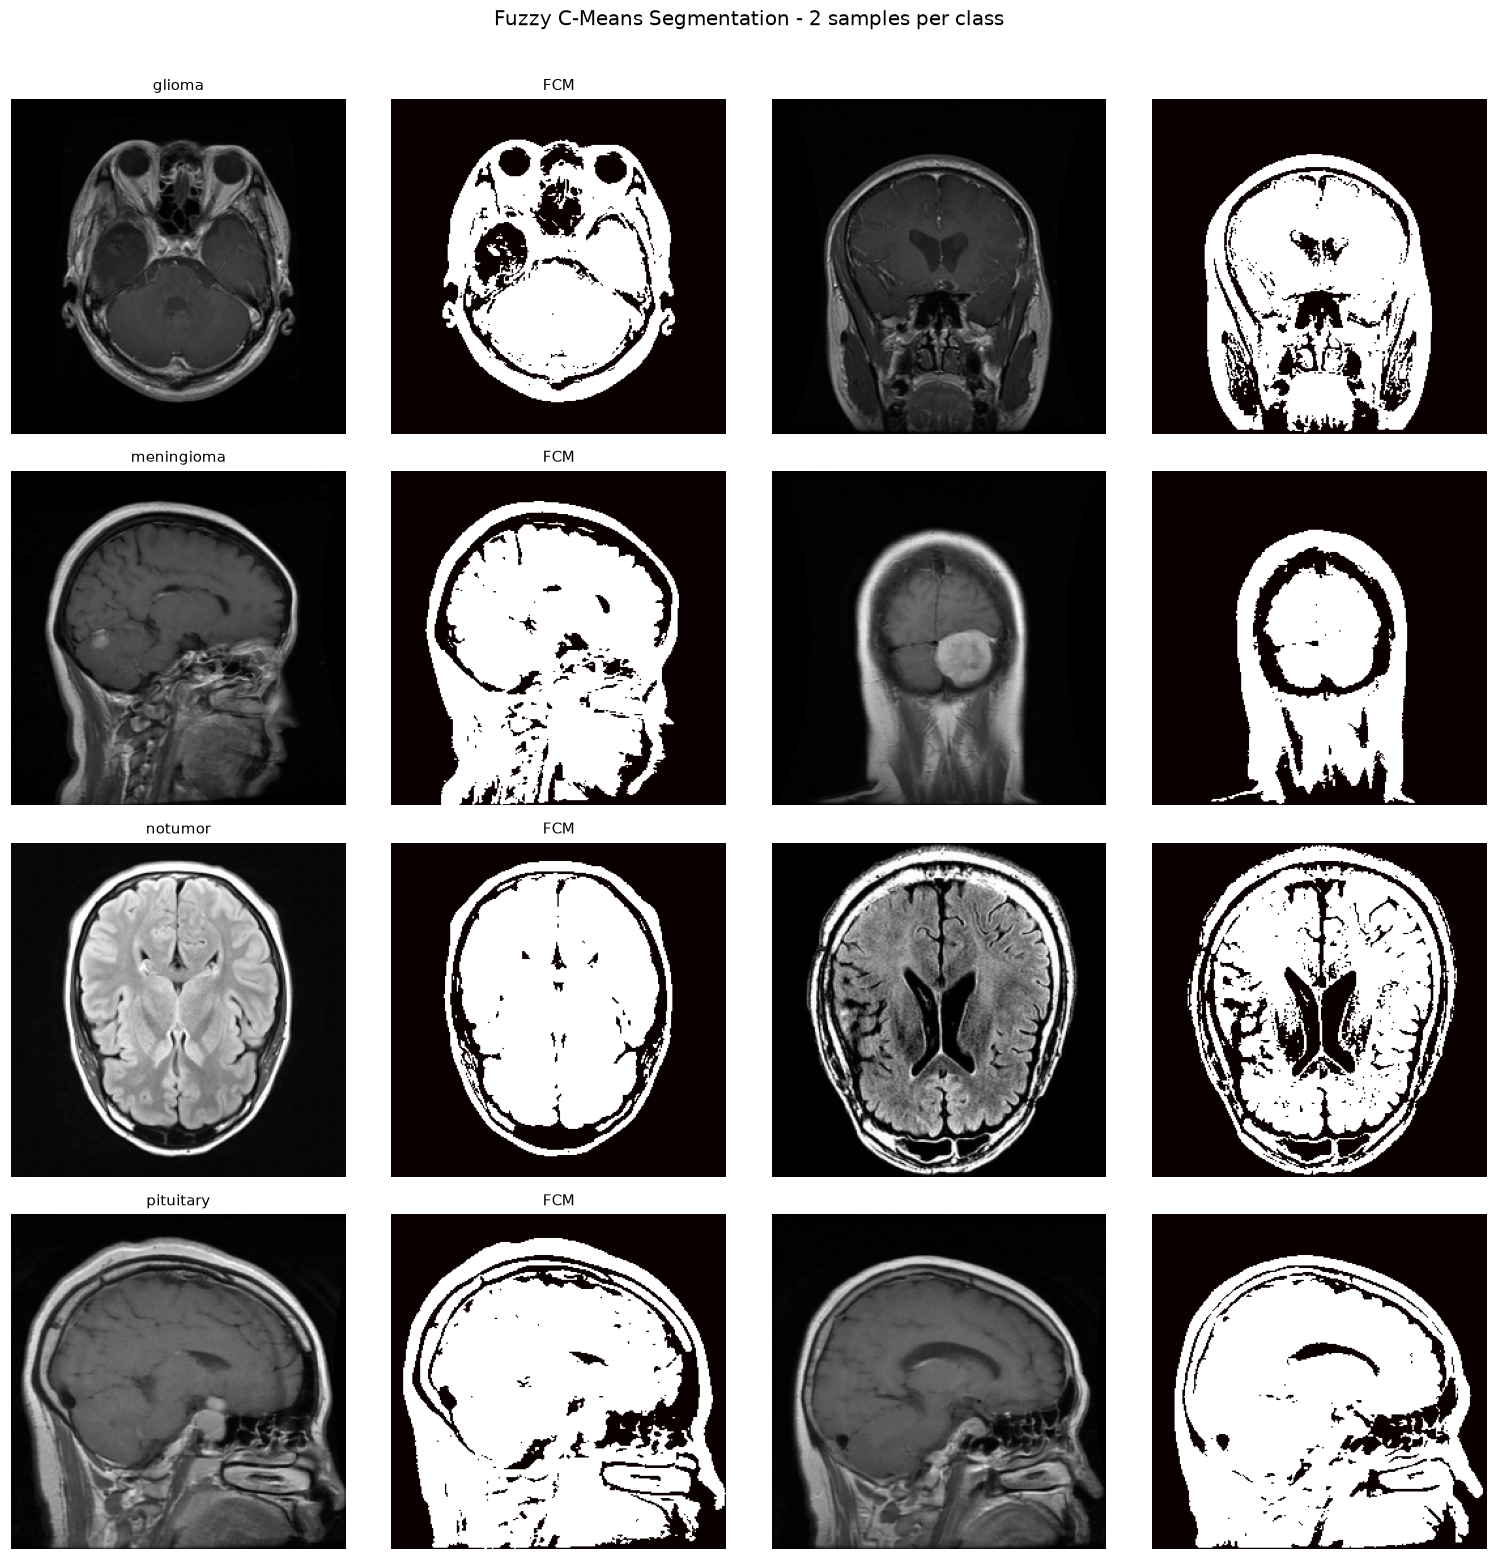

In [10]:
import random
random.seed(42)

SAMPLES_PER_CLASS = 2
fig, axes = plt.subplots(
    len(CLASS_NAMES), SAMPLES_PER_CLASS * 2,
    figsize=(14, 3.5 * len(CLASS_NAMES))
)

for row, cls in enumerate(CLASS_NAMES):
    cls_indices = [
        i for i, y in enumerate(splits['test']['y_multiclass']) if y == row
    ]
    sample_idx = random.sample(cls_indices, SAMPLES_PER_CLASS)

    for col_pair, idx in enumerate(sample_idx):
        path = splits['test']['paths'][idx]
        img  = load_images([path], image_size=IMAGE_SIZE)[0]
        mask, _ = fuzzy_cmeans_segment(img, n_clusters=2)

        ax_img  = axes[row, col_pair * 2]
        ax_mask = axes[row, col_pair * 2 + 1]

        ax_img.imshow(img, cmap='gray')
        ax_img.set_title(cls if col_pair == 0 else '', fontsize=10)
        ax_img.axis('off')

        ax_mask.imshow(mask, cmap='hot')
        ax_mask.set_title('FCM' if col_pair == 0 else '', fontsize=10)
        ax_mask.axis('off')

plt.suptitle('Fuzzy C-Means Segmentation - 2 samples per class',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()